<a href="https://colab.research.google.com/github/spandana9318/Scikit_learn/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import fetch_openml
titanic_data = fetch_openml('titanic', version = 1, as_frame=True)

In [ ]:
df = titanic_data['data']

In [ ]:
df['survived'] = titanic_data['target']

In [ ]:
df.head()


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


<Axes: xlabel='survived', ylabel='count'>

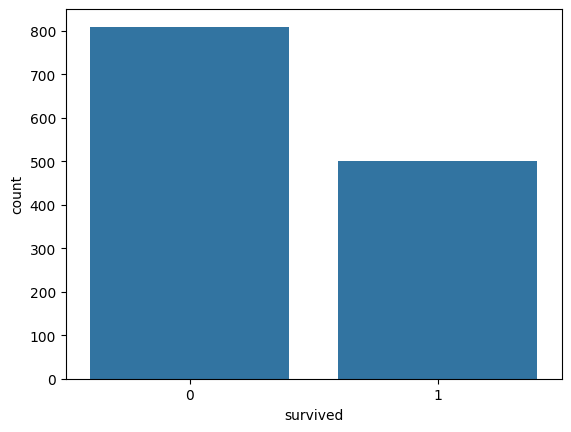

In [ ]:
sns.countplot(x="survived", data=df)

<Axes: xlabel='survived', ylabel='count'>

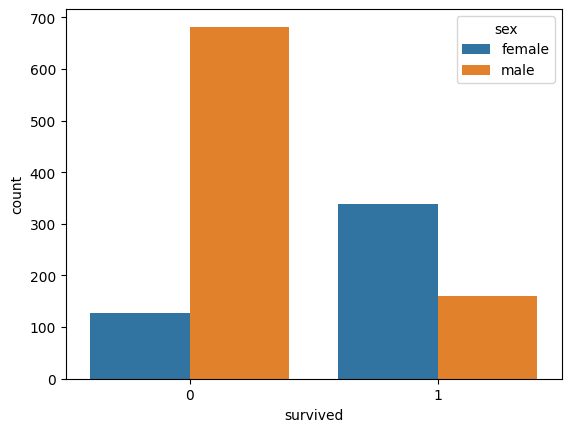

In [ ]:
sns.countplot(x="survived", hue='sex', data=df)

<Axes: xlabel='survived', ylabel='count'>

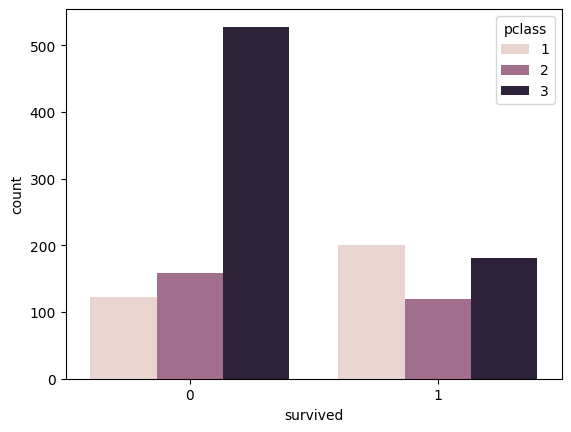

In [ ]:
sns.countplot(x="survived", hue='pclass', data=df)

<Axes: ylabel='Frequency'>

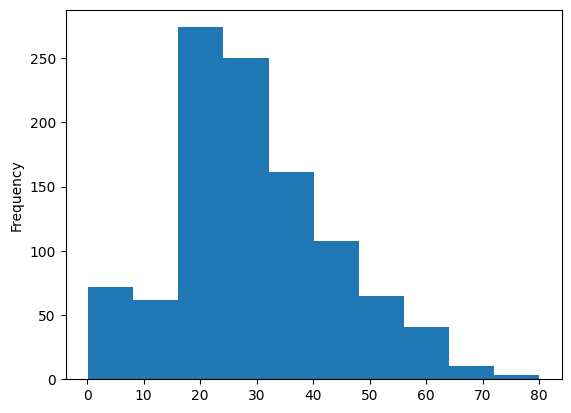

In [ ]:
df['age'].plot.hist()

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   object  
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   object  
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    object  
 9   embarked   1307 non-null   category
 10  boat       486 non-null    object  
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    object  
 13  survived   1309 non-null   category
dtypes: category(3), float64(3), int64(3), object(5)
memory usage: 116.8+ KB


In [ ]:
df.isnull().sum()

,0
pclass,0
name,0
sex,0
age,263
sibsp,0
parch,0
ticket,0
fare,1
cabin,1014
embarked,2


<Axes: title={'center': 'Missing values in percentage'}, ylabel='percentage'>

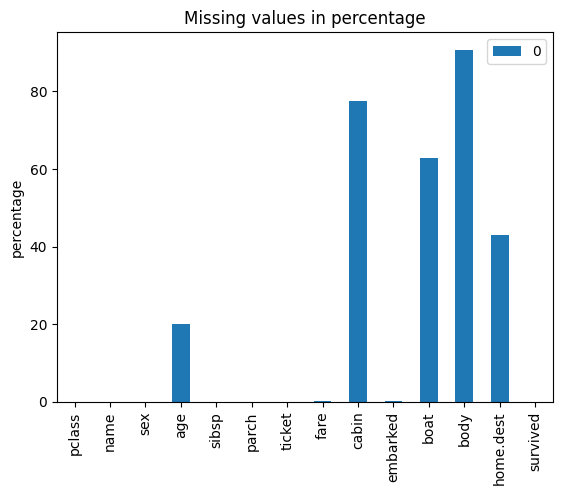

In [ ]:
miss_vals = pd.DataFrame(df.isnull().sum())/len(df)*100
miss_vals.plot(kind='bar', title='Missing values in percentage', ylabel='percentage')

In [ ]:
df['family'] = df['sibsp']+df['parch']
df.loc[df['family']>0,'travelled_alone'] = 0
df.loc[df['family']==0,'travelled_alone'] = 1


In [ ]:
df.head()


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived,family,travelled_alone
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1,0,1.0
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1,3,0.0
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,3,0.0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0,3,0.0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0,3,0.0


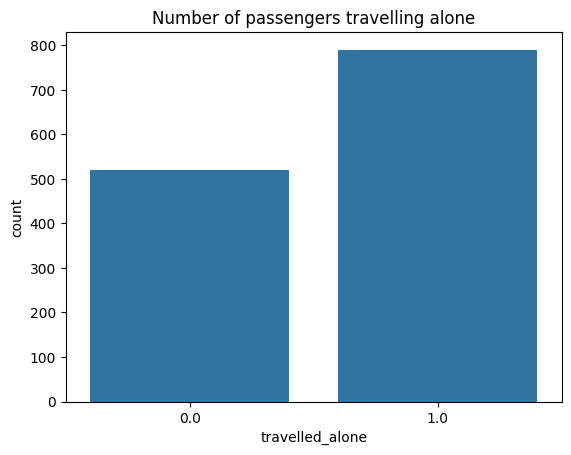

In [ ]:
df.drop(['sibsp', 'parch'], axis=1, inplace=True)
sns.countplot(x='travelled_alone', data = df)
plt.title('Number of passengers travelling alone')
plt.show()

In [ ]:
df.drop(['name',"ticket",'home.dest'], axis=1, inplace=True)

In [ ]:
df.head()

,pclass,sex,age,fare,cabin,embarked,boat,body,survived,family,travelled_alone
0,1,female,29.0000,211.3375,B5,S,2,NaN,1,0,1.0
1,1,male,0.9167,151.5500,C22 C26,S,11,NaN,1,3,0.0
2,1,female,2.0000,151.5500,C22 C26,S,NaN,NaN,0,3,0.0
3,1,male,30.0000,151.5500,C22 C26,S,NaN,135.0,0,3,0.0
4,1,female,25.0000,151.5500,C22 C26,S,NaN,NaN,0,3,0.0


In [ ]:
df.drop(['cabin', 'body', 'boat'], axis=1, inplace=True)

In [ ]:
df.head()

,pclass,sex,age,fare,embarked,survived,family,travelled_alone
0,1,female,29.0000,211.3375,S,1,0,1.0
1,1,male,0.9167,151.5500,S,1,3,0.0
2,1,female,2.0000,151.5500,S,0,3,0.0
3,1,male,30.0000,151.5500,S,0,3,0.0
4,1,female,25.0000,151.5500,S,0,3,0.0


In [ ]:
sex=pd.get_dummies(df['sex'], drop_first=True)
print(sex)

       male
0     False
1      True
2     False
3      True
4     False
...     ...
1304  False
1305  False
1306   True
1307   True
1308   True

[1309 rows x 1 columns]


In [ ]:
df['sex'] = sex

In [ ]:
df.isnull().sum()

,0
pclass,0
sex,0
age,263
fare,1
embarked,2
survived,0
family,0
travelled_alone,0


In [ ]:
from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(strategy='mean')

In [ ]:
df['age'] = imp_mean.fit_transform(df[['age']])
df['fare'] = imp_mean.fit_transform(df[['fare']])

In [ ]:
df.head()

,pclass,sex,age,fare,embarked,survived,family,travelled_alone
0,1,False,29.0000,211.3375,S,1,0,1.0
1,1,True,0.9167,151.5500,S,1,3,0.0
2,1,False,2.0000,151.5500,S,0,3,0.0
3,1,True,30.0000,151.5500,S,0,3,0.0
4,1,False,25.0000,151.5500,S,0,3,0.0


In [ ]:
imp_freq = SimpleImputer(strategy='most_frequent')

In [ ]:
df['embarked'] = imp_freq.fit_transform(df[['embarked']]).ravel()

In [ ]:
df.isnull().sum()

,0
pclass,0
sex,0
age,0
fare,0
embarked,0
survived,0
family,0
travelled_alone,0


In [ ]:
df.head()

,pclass,sex,age,fare,embarked,survived,family,travelled_alone
0,1,False,29.0000,211.3375,S,1,0,1.0
1,1,True,0.9167,151.5500,S,1,3,0.0
2,1,False,2.0000,151.5500,S,0,3,0.0
3,1,True,30.0000,151.5500,S,0,3,0.0
4,1,False,25.0000,151.5500,S,0,3,0.0


In [ ]:
embarked = pd.get_dummies(df['embarked'], drop_first=True, dtype=int)
print(embarked)

KeyError: 'embarked'

In [ ]:
df.drop(['embarked'], axis=1, inplace=True)
df = pd.concat([df,embarked], axis =1)

In [ ]:
df.head()

,pclass,sex,age,fare,survived,family,travelled_alone,Q,S
0,1,False,29.0000,211.3375,1,0,1.0,False,True
1,1,True,0.9167,151.5500,1,3,0.0,False,True
2,1,False,2.0000,151.5500,0,3,0.0,False,True
3,1,True,30.0000,151.5500,0,3,0.0,False,True
4,1,False,25.0000,151.5500,0,3,0.0,False,True


In [ ]:
X = df.drop(['survived'], axis=1)
X.head()

,pclass,sex,age,fare,family,travelled_alone,Q,S
0,1,False,29.0000,211.3375,0,1.0,False,True
1,1,True,0.9167,151.5500,3,0.0,False,True
2,1,False,2.0000,151.5500,3,0.0,False,True
3,1,True,30.0000,151.5500,3,0.0,False,True
4,1,False,25.0000,151.5500,3,0.0,False,True


In [ ]:
y=df['survived']
y.head()

,survived
0,1
1,1
2,0
3,0
4,0


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [ ]:
print(X_train.shape, y_train.shape)

(916, 8) (916,)


In [ ]:
from sklearn.linear_model import LinearRegression
mod = LinearRegression()
mod.fit(X_train,y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import accuracy_score
pred = mod.predict(X_test)


In [ ]:
print(y_test)

201     0
115     0
255     1
1103    0
195     1
       ..
226     0
1192    0
180     1
191     0
348     0
Name: survived, Length: 393, dtype: category
Categories (2, object): ['0', '1']


In [ ]:
df

,pclass,sex,age,fare,survived,family,travelled_alone,Q,S
0,1,0,29.000000,211.3375,1,0,1.0,0,1
1,1,1,0.916700,151.5500,1,3,0.0,0,1
2,1,0,2.000000,151.5500,0,3,0.0,0,1
3,1,1,30.000000,151.5500,0,3,0.0,0,1
4,1,0,25.000000,151.5500,0,3,0.0,0,1
...,...,...,...,...,...,...,...,...,...
1304,3,0,14.500000,14.4542,0,1,0.0,0,0
1305,3,0,29.881135,14.4542,0,1,0.0,0,0
1306,3,1,26.500000,7.2250,0,0,1.0,0,0
1307,3,1,27.000000,7.2250,0,0,1.0,0,0


In [ ]:
print(y_test.shape)

(393,)


In [ ]:
accuracy_score(y_test, pred)

ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [ ]:
df['Q'] = df['Q'].astype(int)
df['S'] = df['S'].astype(int)
df['sex'] = df['sex'].astype(int)

In [ ]:
df.head()

,pclass,sex,age,fare,survived,family,travelled_alone,Q,S
0,1,0,29.0000,211.3375,1,0,1.0,0,1
1,1,1,0.9167,151.5500,1,3,0.0,0,1
2,1,0,2.0000,151.5500,0,3,0.0,0,1
3,1,1,30.0000,151.5500,0,3,0.0,0,1
4,1,0,25.0000,151.5500,0,3,0.0,0,1


In [ ]:
df.isnull().sum()

,0
pclass,0
sex,0
age,0
fare,0
survived,0
family,0
travelled_alone,0
Q,0
S,0


In [ ]:
pred

array([ 0.27370297,  0.14636283,  0.98314923,  0.11790996,  0.9583927 ,
        0.11497823,  0.07082392,  0.76830953,  0.99852133,  0.38529988,
       -0.07139563,  0.16444029,  0.14351184,  0.7128956 ,  0.20157047,
        0.87705506,  0.58718801,  0.59571014,  0.17343774,  0.14842527,
        0.05680507,  0.053774  ,  0.91376221,  0.11527389,  0.11527389,
        0.43579163,  0.07095104, -0.13217842,  0.1646466 ,  0.33027676,
        0.0592096 ,  0.05918434,  0.89580317,  0.26862616,  0.14269839,
        0.95886534,  0.63993786,  0.99712725,  0.0709544 ,  0.32630112,
        0.14029466,  0.58767846,  0.11527389,  0.09806192,  0.67904448,
        0.31419562,  0.07420875,  0.45115754,  0.17970345,  0.84087331,
        0.65618388,  0.07083655,  0.5949384 ,  0.14351269,  0.5369488 ,
        0.69066492,  0.39638059,  0.10721001,  0.30729805,  0.11527389,
       -0.04658731,  0.08173323,  0.23331423,  0.07088453,  1.00966229,
        0.09648686,  0.53771908,  0.90470399,  0.34159414,  0.12

In [ ]:

pred_class = (pred >= 0.5).astype(int)


In [ ]:
accuracy_score(y_test, pred_class)

TypeError: Labels in y_true and y_pred should be of the same type. Got y_true=['0' '1'] and y_pred=[0 1]. Make sure that the predictions provided by the classifier coincides with the true labels.

In [ ]:
print(type(y_test), type(pred))

<class 'pandas.core.series.Series'> <class 'numpy.ndarray'>


In [ ]:
y_test = y_test.astype(int)
pred = pred.astype(int)

print("Accuracy:", accuracy_score(y_test, pred))


Accuracy: 0.6132315521628499


In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, pred)

array([[236,   0],
       [152,   5]])